In [4]:
import xarray as xr

ds = xr.open_dataset("single-point-timeseries_all_vars.nc")

print(ds)

print(ds.latitude.values)
print(ds.longitude.values)

<xarray.Dataset> Size: 948kB
Dimensions:     (valid_time: 26328)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 211kB 2023-01-01 ... 2026-01-01T2...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    u10         (valid_time) float32 105kB ...
    v10         (valid_time) float32 105kB ...
    t2m         (valid_time) float32 105kB ...
    sp          (valid_time) float32 105kB ...
    ssrd        (valid_time) float32 105kB ...
    tcc         (valid_time) float32 105kB ...
    tp          (valid_time) float32 105kB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts
55.75
12.5


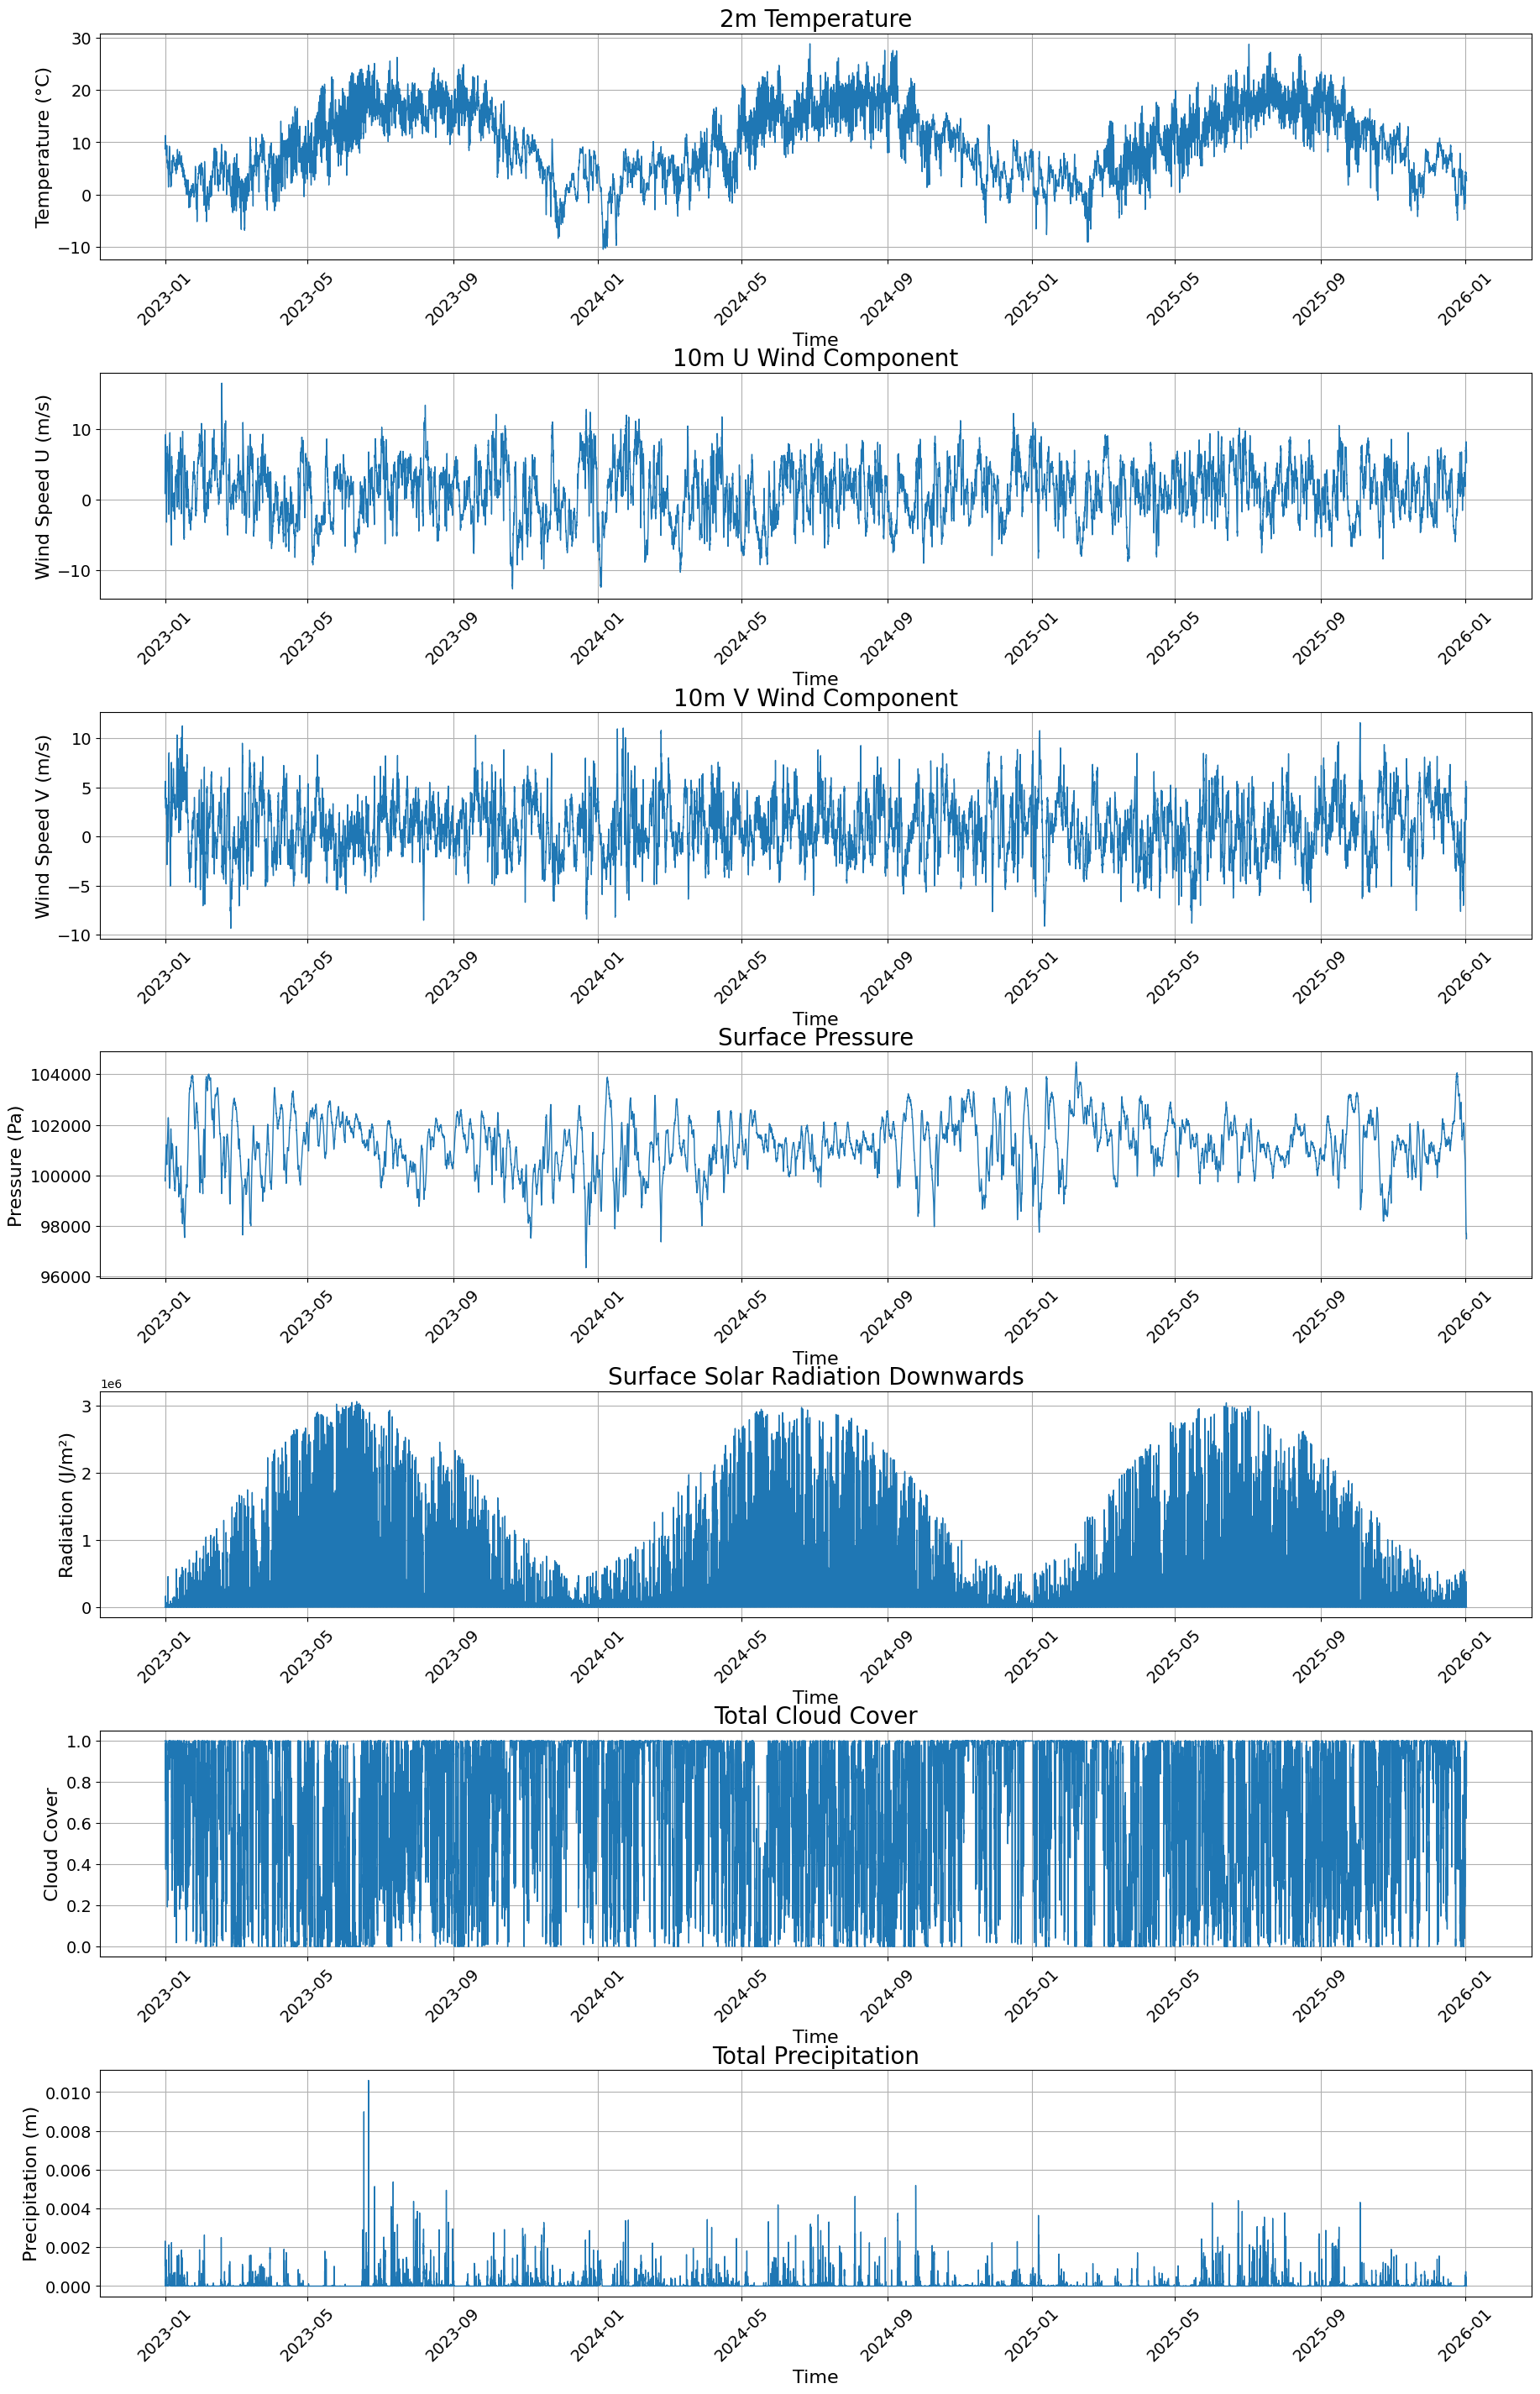

In [6]:
import matplotlib.pyplot as plt

df = ds.to_dataframe()

df["t2m"] = df["t2m"] - 273.15

variables = ["t2m", "u10", "v10", "sp", "ssrd", "tcc", "tp"]

titles = {
    "t2m": "2m Temperature",
    "u10": "10m U Wind Component",
    "v10": "10m V Wind Component",
    "sp": "Surface Pressure",
    "ssrd": "Surface Solar Radiation Downwards",
    "tcc": "Total Cloud Cover",
    "tp": "Total Precipitation"
}

ylabels = {
    "t2m": "Temperature (°C)",
    "u10": "Wind Speed U (m/s)",
    "v10": "Wind Speed V (m/s)",
    "sp": "Pressure (Pa)",
    "ssrd": "Radiation (J/m²)",
    "tcc": "Cloud Cover",
    "tp": "Precipitation (m)"
}

fig, axes = plt.subplots(
    len(variables),
    1,
    figsize=(22, 35),
    sharex=False)   

for ax, var in zip(axes, variables):

    ax.plot(df.index, df[var], linewidth=1)

    ax.set_title(titles[var], fontsize=20)
    ax.set_ylabel(ylabels[var], fontsize=16)
    ax.set_xlabel("Time", fontsize=16)

    ax.tick_params(axis='both', labelsize=14)

    ax.tick_params(axis='x', rotation=45)

    ax.grid(True)

plt.subplots_adjust(hspace=0.5)

plt.show()

RANDOM FOREST REGRESSOR - same time(not future prediction)

MSE: 0.1083656849025776
MAE: 0.13545555575827523


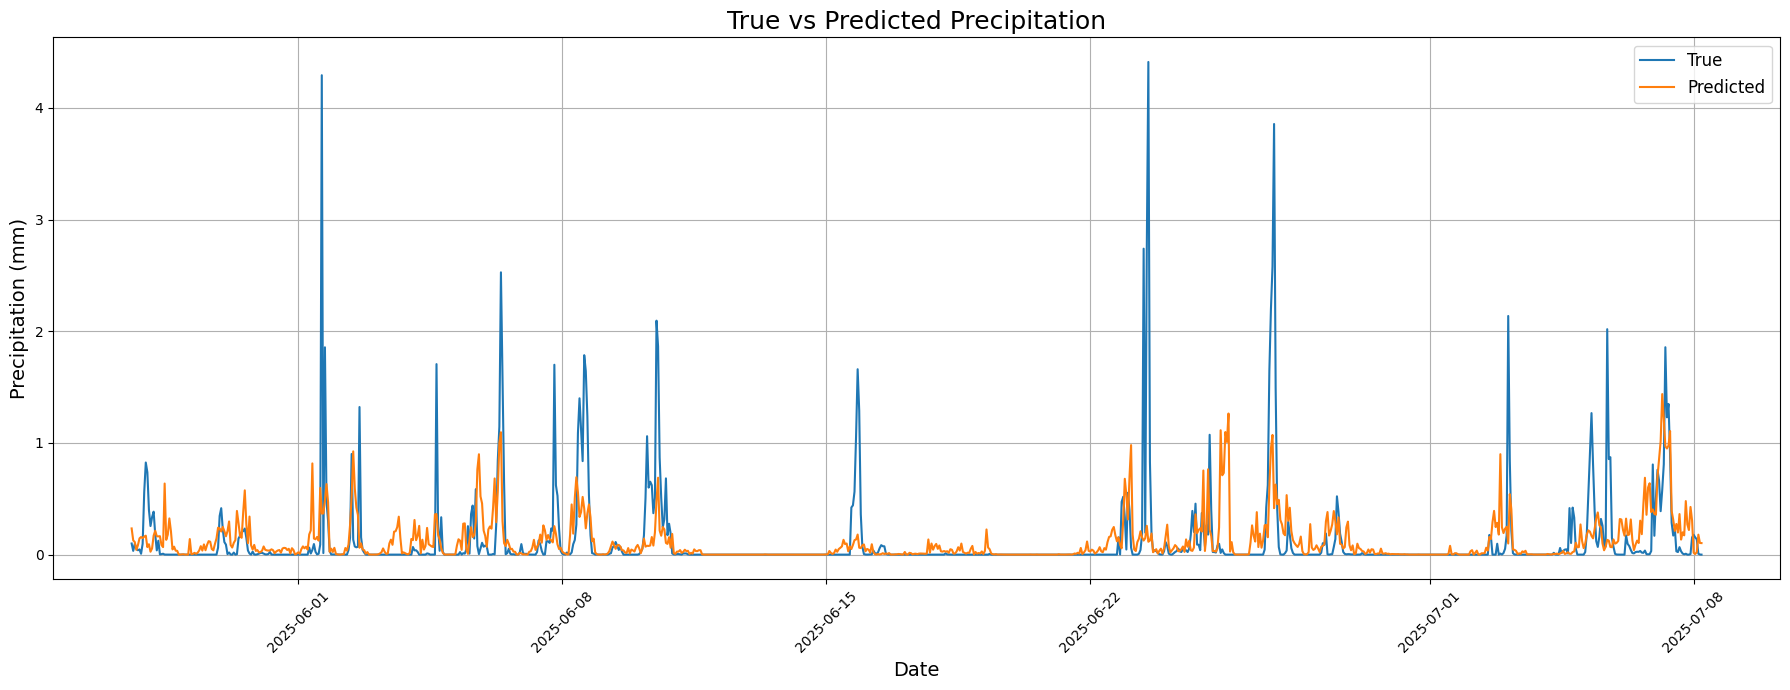

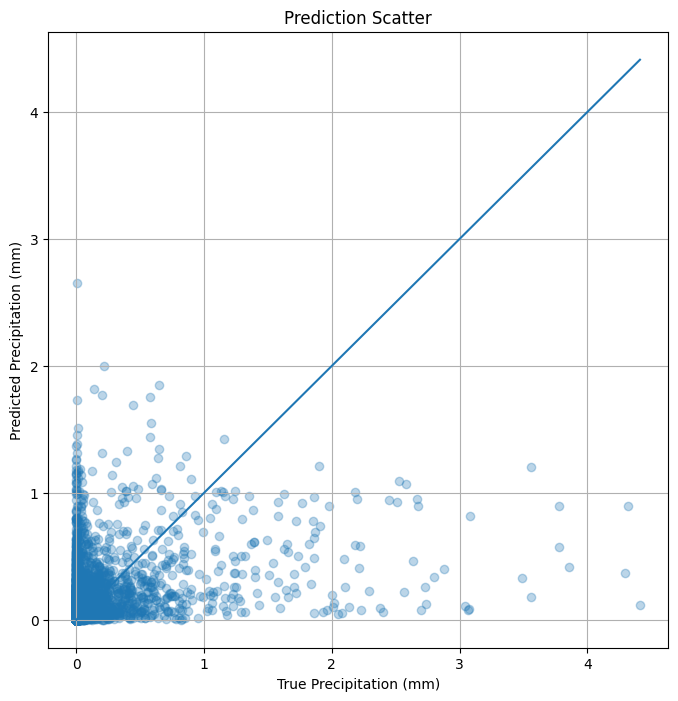


TRAIN RANGE:
2023-01-01 00:00:00 -> 2025-05-27 13:00:00

TEST RANGE:
2025-05-27 14:00:00 -> 2026-01-01 23:00:00


In [7]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Convert temperature from Kelvin to Celsius
df["t2m"] = df["t2m"] - 273.15

# Convert precipitation from meters to mm
df["tp"] = df["tp"] * 1000

# create wind speed
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

features = [
    "t2m",
    "u10",
    "v10",
    "wind_speed",
    "sp",
    "ssrd",
    "tcc"
]

target = "tp"

data = df[features + [target]].copy()


data = data.dropna()

#train/test split

split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index]
test_data  = data.iloc[split_index:]

X_train = train_data[features]
y_train = train_data[target]

X_test = test_data[features]
y_test = test_data[target]

#model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

#train
model.fit(X_train, y_train)

#predict
preds = model.predict(X_test)

#metrics

mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("MSE:", mse)
print("MAE:", mae)

#plot

plot_df = pd.DataFrame({
    "True": y_test,
    "Predicted": preds
}, index=y_test.index)


plot_df = plot_df.sort_index()

plt.figure(figsize=(18,7))

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True",
    linewidth=1.5
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Precipitation (mm)", fontsize=14)
plt.title("True vs Predicted Precipitation", fontsize=18)

plt.xticks(rotation=45)

plt.grid(True)
plt.legend(fontsize=12)

plt.tight_layout()

plt.show()

#scatter

plt.figure(figsize=(8,8))

plt.scatter(y_test, preds, alpha=0.3)


m = max(y_test.max(), preds.max())

plt.plot([0, m], [0, m])

plt.xlabel("True Precipitation (mm)")
plt.ylabel("Predicted Precipitation (mm)")
plt.title("Prediction Scatter")

plt.grid(True)

plt.show()

#train/test ranges

print("\nTRAIN RANGE:")
print(y_train.index.min(), "->", y_train.index.max())

print("\nTEST RANGE:")
print(y_test.index.min(), "->", y_test.index.max())

Random Forest Regressor - 1 hour prediction based on 24 previous hours

MSE: 0.09135484157328354
MAE: 0.07971687184803279


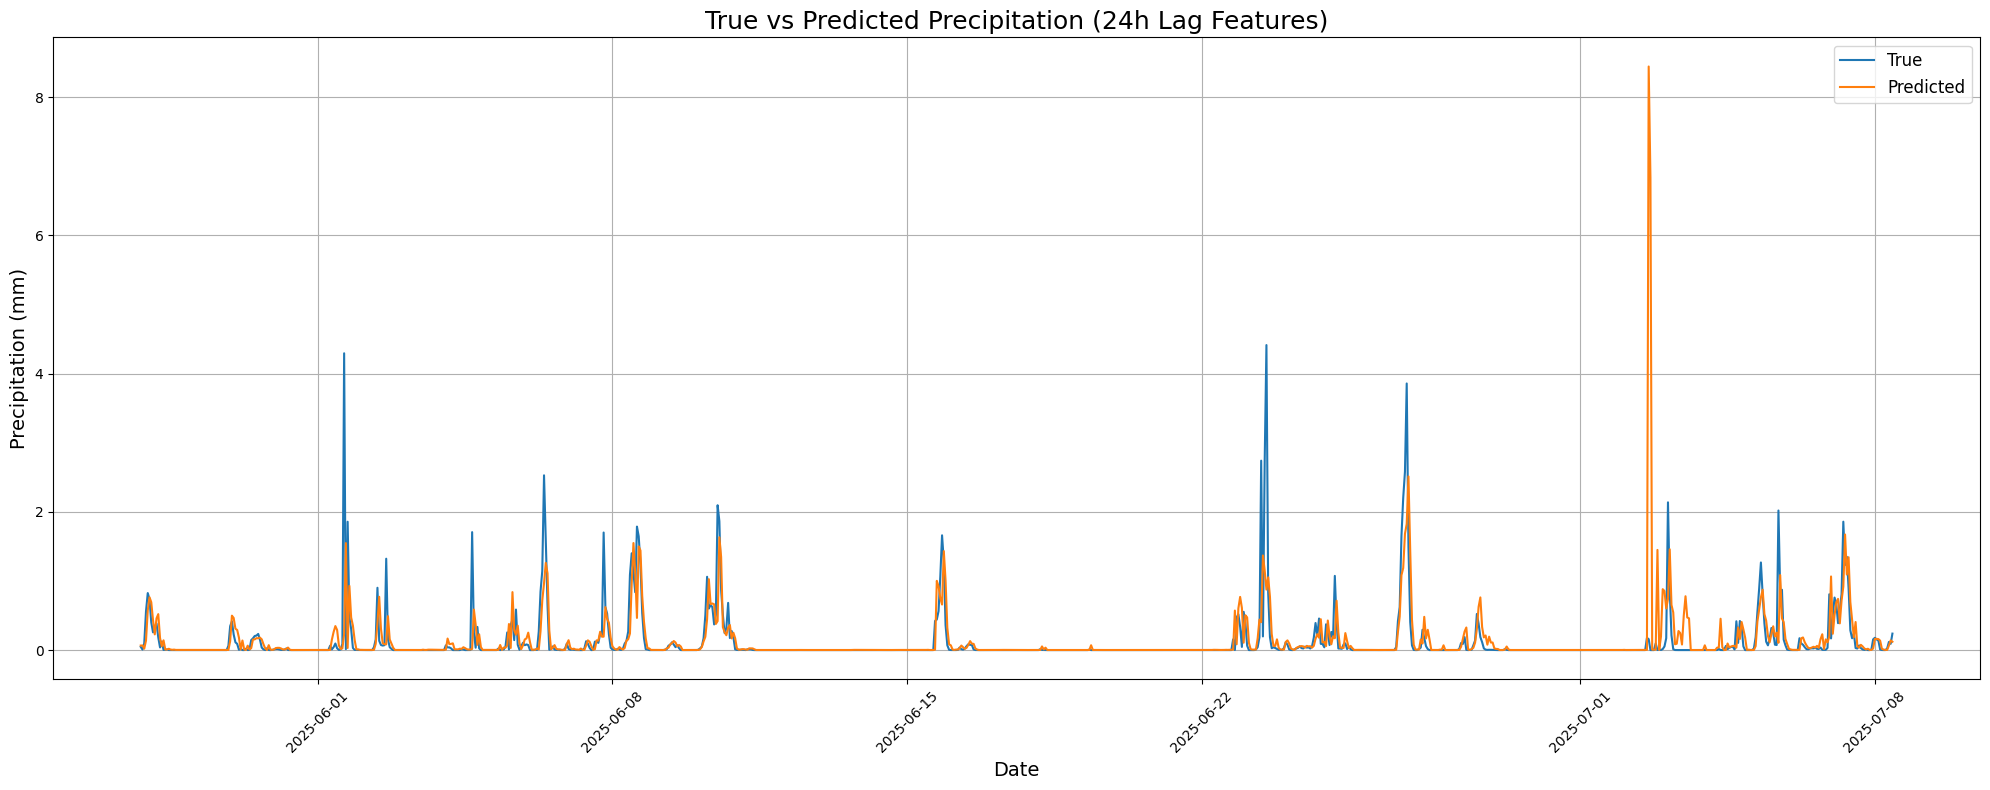

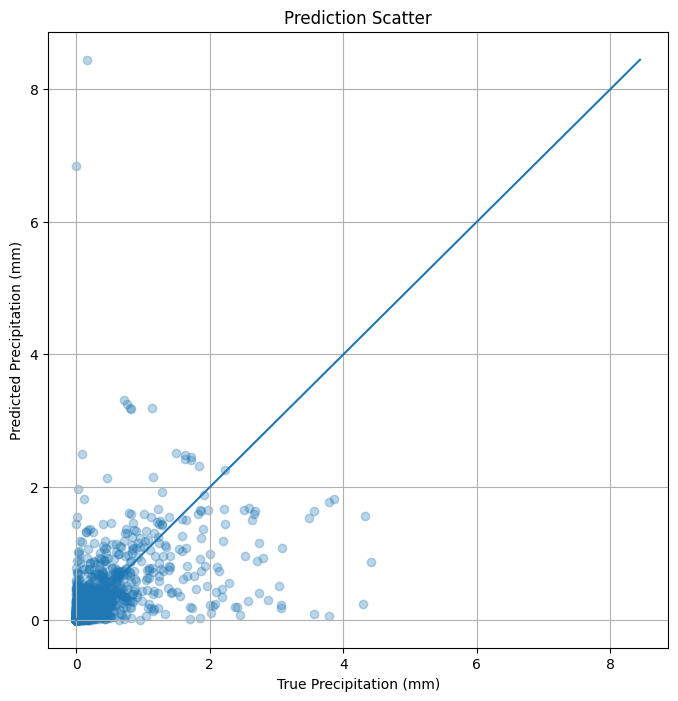

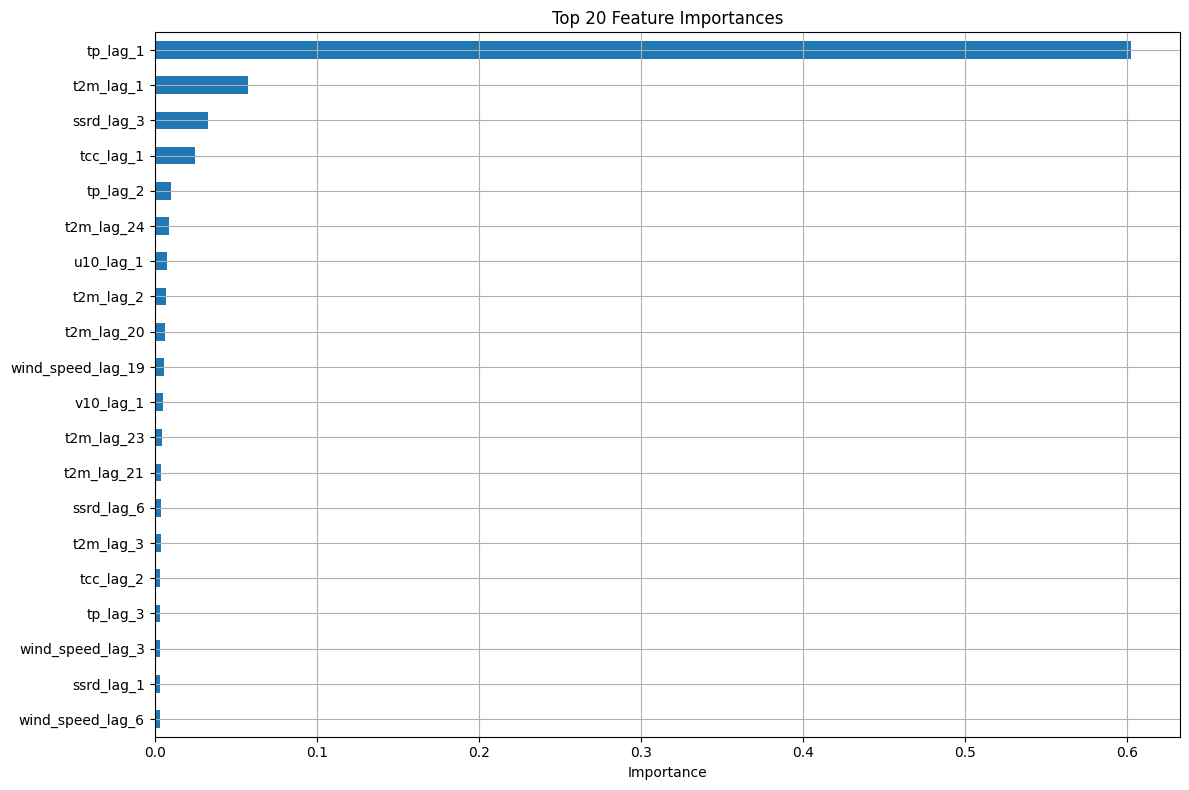


TRAIN RANGE:
2023-01-02 00:00:00 -> 2025-05-27 18:00:00

TEST RANGE:
2025-05-27 19:00:00 -> 2026-01-01 23:00:00


In [8]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

ds = xr.open_dataset("single-point-timeseries_all_vars.nc")

df = ds.to_dataframe()

# Temperature: Kelvin -> Celsius
df["t2m"] = df["t2m"] - 273.15

# Precipitation: meters -> mm
df["tp"] = df["tp"] * 1000

# Wind speed
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

base_features = [
    "t2m",
    "u10",
    "v10",
    "wind_speed",
    "sp",
    "ssrd",
    "tcc",
    "tp"
]

#24-hour lag features

lagged_data = {}

for lag in range(1, 25):

    for feature in base_features:

        lagged_data[f"{feature}_lag_{lag}"] = df[feature].shift(lag)


lagged_df = pd.DataFrame(lagged_data, index=df.index)


# Use ONLY lag features
X = lagged_df.copy()

#target
y = df["tp"]

data = pd.concat([X, y], axis=1)

data = data.dropna()


X = data.drop(columns=["tp"])
y = data["tp"]

#train/test split

split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

#model

model = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

#metrics

mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("MSE:", mse)
print("MAE:", mae)

# plot

plot_df = pd.DataFrame({
    "True": y_test,
    "Predicted": preds
}, index=y_test.index)

plot_df = plot_df.sort_index()

plt.figure(figsize=(20,8))

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True",
    linewidth=1.5
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date", fontsize=14)
plt.ylabel("Precipitation (mm)", fontsize=14)

plt.title(
    "True vs Predicted Precipitation (24h Lag Features)",
    fontsize=18
)

plt.xticks(rotation=45)

plt.grid(True)
plt.legend(fontsize=12)

plt.tight_layout()

plt.show()


plt.figure(figsize=(8,8))

plt.scatter(y_test, preds, alpha=0.3)

# Ideal line
m = max(y_test.max(), preds.max())

plt.plot([0, m], [0, m])

plt.xlabel("True Precipitation (mm)")
plt.ylabel("Predicted Precipitation (mm)")

plt.title("Prediction Scatter")

plt.grid(True)

plt.show()

#feature importance

importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

# Top 20 features
top_importances = importances.sort_values(
    ascending=False
).head(20)

plt.figure(figsize=(12,8))

top_importances.plot(kind="barh")

plt.xlabel("Importance")
plt.title("Top 20 Feature Importances")

plt.gca().invert_yaxis()

plt.grid(True)

plt.tight_layout()

plt.show()


print("\nTRAIN RANGE:")
print(y_train.index.min(), "->", y_train.index.max())

print("\nTEST RANGE:")
print(y_test.index.min(), "->", y_test.index.max())

XGBoost - 1 hour into the future prediction based on previous 24 hours

MSE: 0.07213138788938522
MAE: 0.07967151701450348


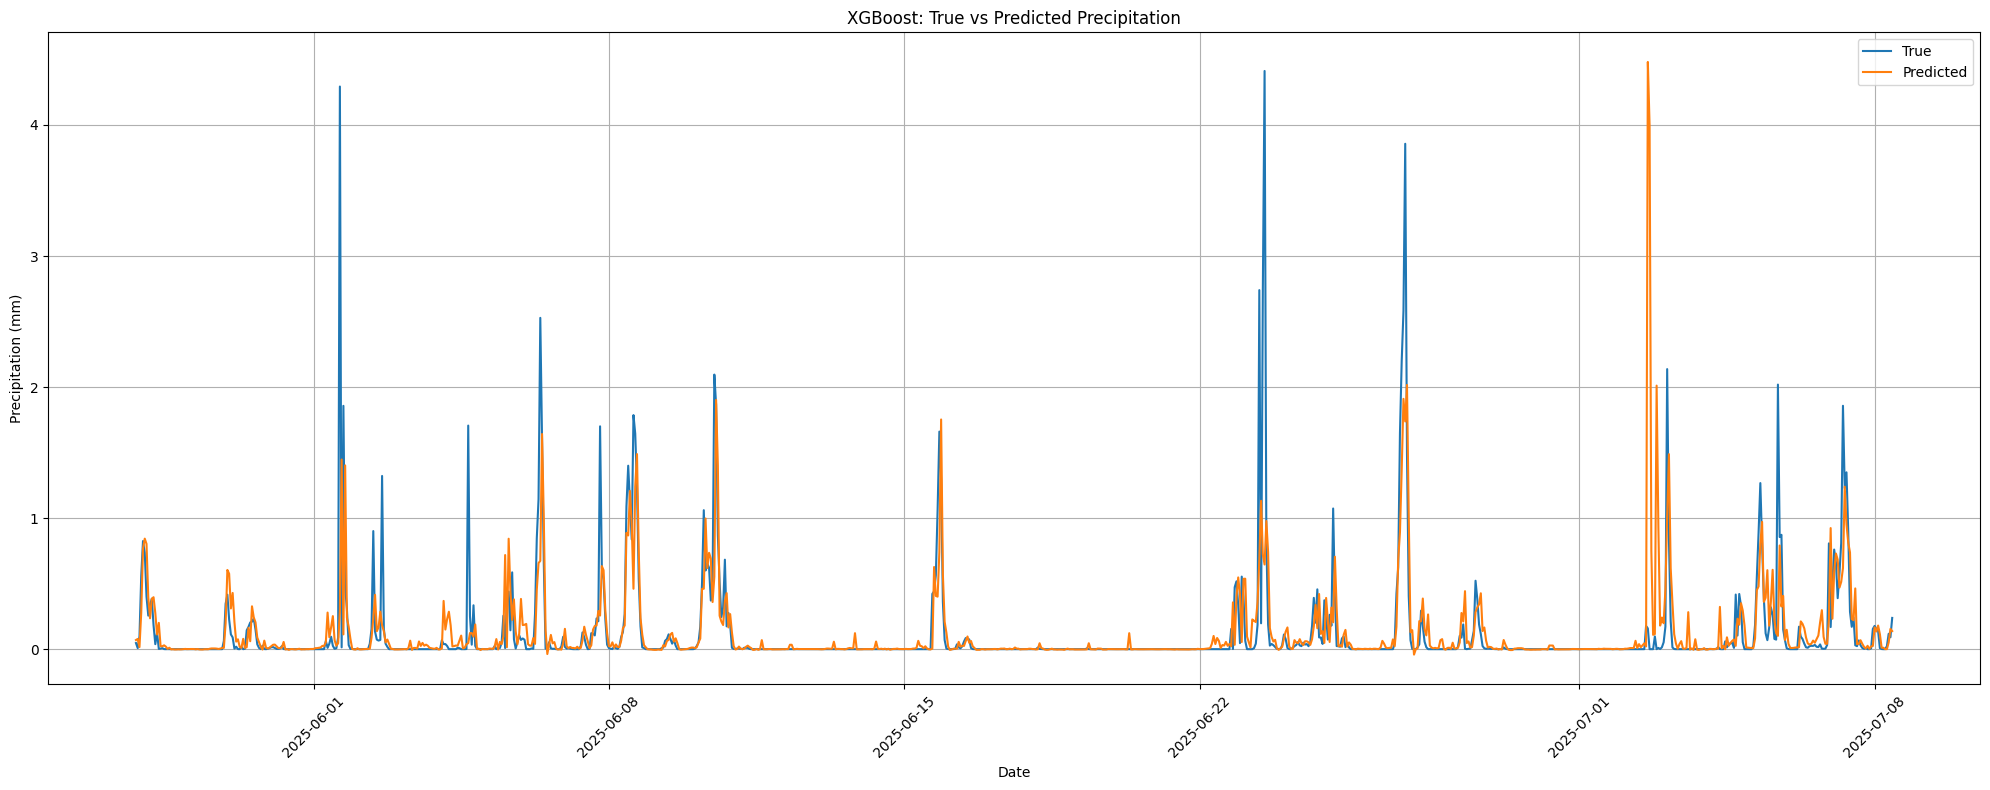

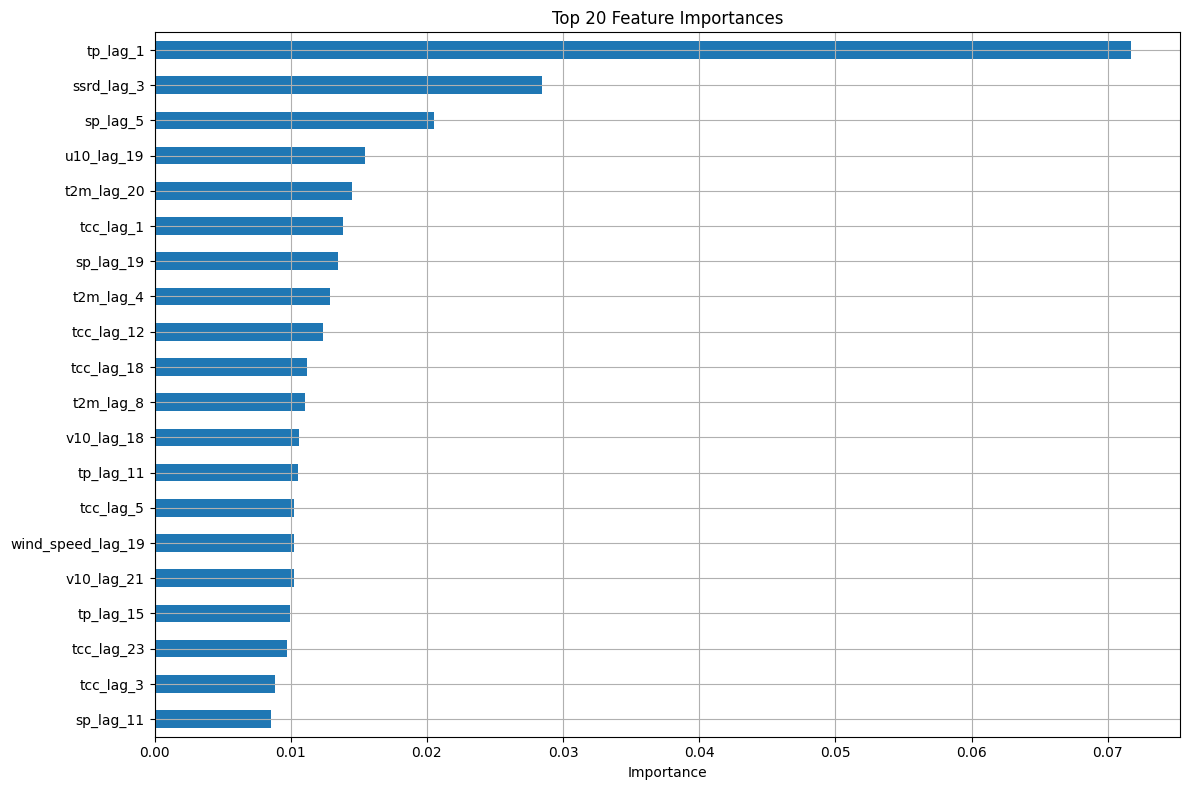

In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error


ds = xr.open_dataset("single-point-timeseries_all_vars.nc")

df = ds.to_dataframe()


# Temperature: Kelvin -> Celsius
df["t2m"] = df["t2m"] - 273.15

# Precipitation: meters -> mm
df["tp"] = df["tp"] * 1000

# Wind speed
df["wind_speed"] = np.sqrt(df["u10"]**2 + df["v10"]**2)

# =========================================================
# BASE FEATURES
# =========================================================

base_features = [
    "t2m",
    "u10",
    "v10",
    "wind_speed",
    "sp",
    "ssrd",
    "tcc",
    "tp"
    
#24h lag

lagged_data = {}

for lag in range(1, 25):

    for feature in base_features:

        lagged_data[f"{feature}_lag_{lag}"] = (
            df[feature].shift(lag)
        )


lagged_df = pd.DataFrame(
    lagged_data,
    index=df.index
)


X = lagged_df.copy()

y = df["tp"]

data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data.drop(columns=["tp"])
y = data["tp"]

#train/test split

split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

#model

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

#metrics

mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("MSE:", mse)
print("MAE:", mae)

#plot
plot_df = pd.DataFrame({
    "True": y_test,
    "Predicted": preds
}, index=y_test.index)

plot_df = plot_df.sort_index()

plt.figure(figsize=(20,8))

plt.plot(
    plot_df.index[:1000],
    plot_df["True"][:1000],
    label="True",
    linewidth=1.5
)

plt.plot(
    plot_df.index[:1000],
    plot_df["Predicted"][:1000],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")

plt.title(
    "XGBoost: True vs Predicted Precipitation"
)

plt.xticks(rotation=45)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()

#feature importanec

importances = pd.Series(
    model.feature_importances_,
    index=X_train.columns
)

top_importances = (
    importances
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

top_importances.plot(kind="barh")

plt.xlabel("Importance")

plt.title("Top 20 Feature Importances")

plt.gca().invert_yaxis()

plt.grid(True)

plt.tight_layout()

plt.show()

C:\Users\Vasileios\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0708
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0500
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0481
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0473
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0468
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0464
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0461
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0453
Epoch 9/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0452
Epoch 10/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0447
Epoch 11/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0443
Epoch 12/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0439
Epoch 13/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0434
Epoch 14/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0428
Epoch 15/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s

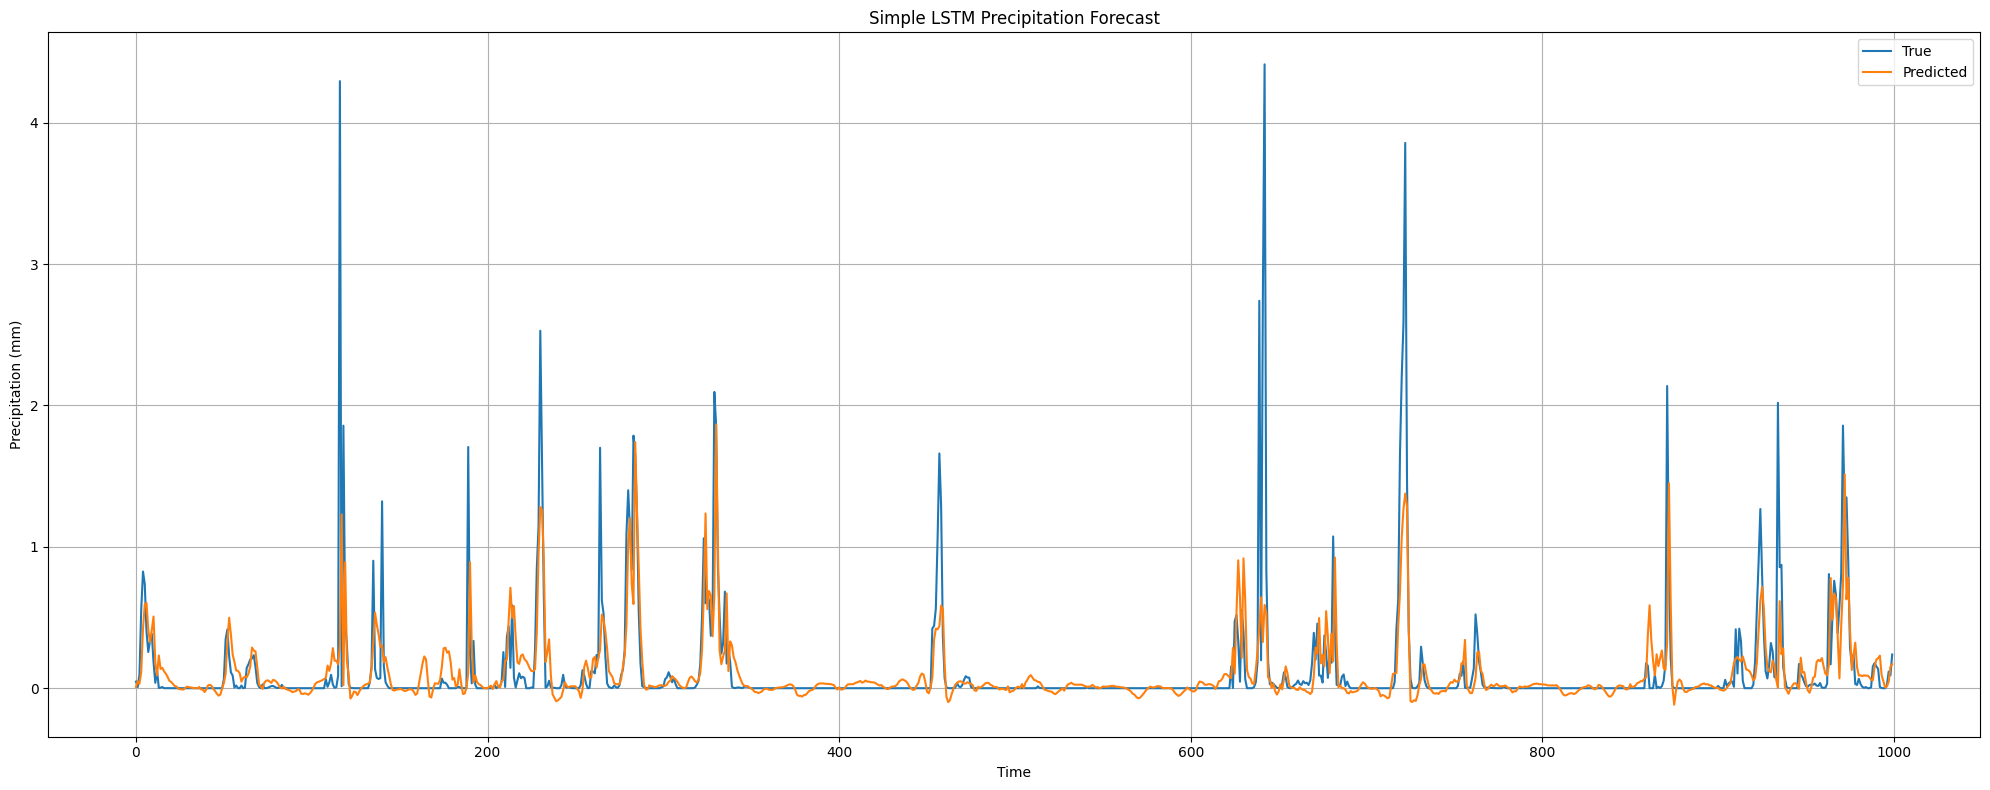

In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


ds = xr.open_dataset(
    "single-point-timeseries_all_vars.nc"
)

df = ds.to_dataframe()


# Temperature: Kelvin -> Celsius
df["t2m"] = df["t2m"] - 273.15

# Precipitation: meters -> mm
df["tp"] = df["tp"] * 1000

# Wind speed
df["wind_speed"] = np.sqrt(
    df["u10"]**2 + df["v10"]**2
)

features = [
    "t2m",
    "u10",
    "v10",
    "wind_speed",
    "sp",
    "ssrd",
    "tcc",
    "tp"
]

target = "tp"


data = df[features].dropna()

#normalize

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features,
    index=data.index
)


SEQUENCE_LENGTH = 24

X = []
y = []

for i in range(SEQUENCE_LENGTH, len(scaled_df)):

    # Previous 24 hours
    X.append(
        scaled_df.iloc[i-SEQUENCE_LENGTH:i].values
    )

    # Current precipitation
    y.append(
        data[target].iloc[i]
    )

X = np.array(X)
y = np.array(y)

#train/test split

split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test  = X[split_index:]

y_train = y[:split_index]
y_test  = y[split_index:]

#model

model = Sequential()

model.add(
    LSTM(
        32,
        input_shape=(
            X_train.shape[1],
            X_train.shape[2]
        )
    )
)

model.add(Dense(1))


model.compile(
    optimizer="adam",
    loss="mse"
)

#train

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    verbose=1
)


preds = model.predict(X_test).flatten()

#metrics

mse = mean_squared_error(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print("MSE:", mse)
print("MAE:", mae)


plt.figure(figsize=(20,8))

plt.plot(
    y_test[:1000],
    label="True",
    linewidth=1.5
)

plt.plot(
    preds[:1000],
    label="Predicted",
    linewidth=1.5
)

plt.xlabel("Time")
plt.ylabel("Precipitation (mm)")

plt.title(
    "Simple LSTM Precipitation Forecast"
)

plt.grid(True)
plt.legend()

plt.tight_layout()

plt.show()

Rain/No rain Analysis - based on LSTM result


RAIN / NO-RAIN METRICS
------------------------
Accuracy : 0.8800608249382247
Precision: 0.5707885304659498
Recall   : 0.8073510773130546
F1 Score : 0.6687664041994751

Confusion Matrix:
[[3993  479]
 [ 152  637]]


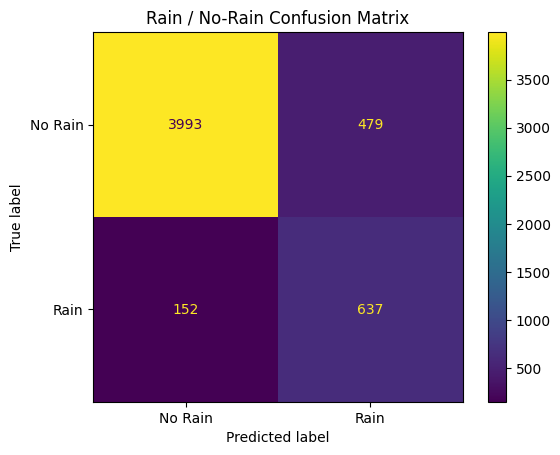

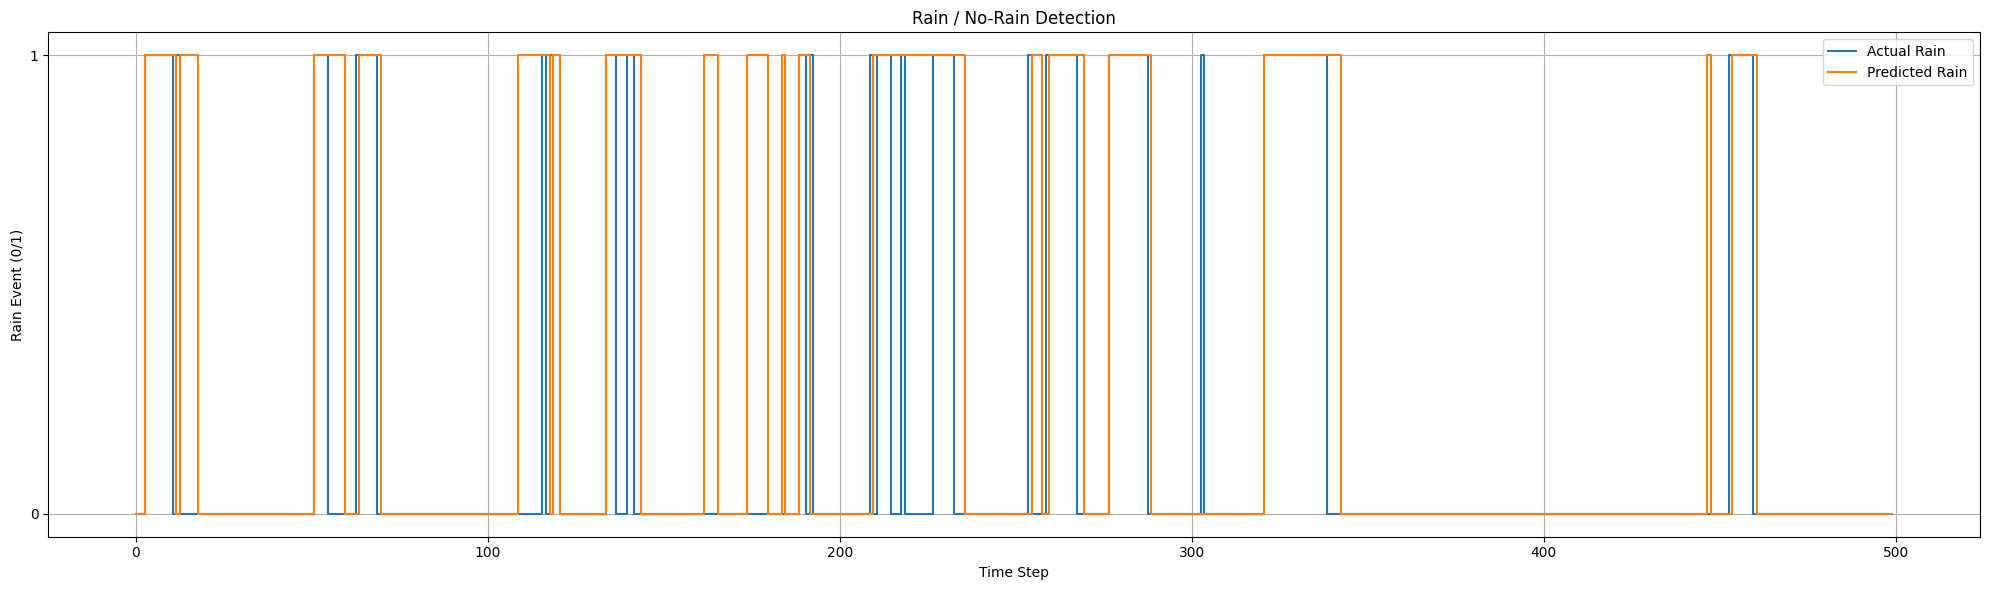


Actual Rain Frequency:
0.14997148831020718

Predicted Rain Frequency:
0.212126972058544


In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


RAIN_THRESHOLD = 0.1  #mm



actual_rain = (
    y_test > RAIN_THRESHOLD
).astype(int)

predicted_rain = (
    preds > RAIN_THRESHOLD
).astype(int)

#metrics

acc = accuracy_score(
    actual_rain,
    predicted_rain
)

prec = precision_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

rec = recall_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

f1 = f1_score(
    actual_rain,
    predicted_rain,
    zero_division=0
)

print("\nRAIN / NO-RAIN METRICS")
print("------------------------")

print("Accuracy :", acc)
print("Precision:", prec)
print("Recall   :", rec)
print("F1 Score :", f1)

#confusion matrix

cm = confusion_matrix(
    actual_rain,
    predicted_rain
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain", "Rain"]
)

disp.plot()

plt.title("Rain / No-Rain Confusion Matrix")

plt.show()

#event plot

plt.figure(figsize=(20,6))

plt.step(
    range(500),
    actual_rain[:500],
    where="mid",
    label="Actual Rain"
)

plt.step(
    range(500),
    predicted_rain[:500],
    where="mid",
    label="Predicted Rain"
)

plt.xlabel("Time Step")

plt.ylabel("Rain Event (0/1)")

plt.title(
    "Rain / No-Rain Detection"
)

plt.yticks([0,1])

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

#event frequencies

print("\nActual Rain Frequency:")
print(actual_rain.mean())

print("\nPredicted Rain Frequency:")
print(predicted_rain.mean())